#  Strategic Analysis of US Superstore Performance
**Daily Challenge Submission**

## Executive Summary
This notebook provides a comprehensive diagnostic analysis of the US Superstore dataset to uncover profitability bottlenecks and geographic trends. 

**Key Findings Overview:**
1. **Discount Thresholds:** Discounts exceeding 20% severely impact profitability, particularly in the Furniture category.
2. **Top Performers:** A small subset of products drives the majority of the profit.
3. **Geographic Concentration:** Sales are heavily concentrated in top-performing states, suggesting opportunities for targeted marketing in underperforming regions.

In [1]:
# Importation des librairies nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from ipywidgets import interact, Dropdown, IntSlider
from IPython.display import display
import warnings
import time

# Ignorer les avertissements pour garder un notebook propre
warnings.filterwarnings('ignore')

# Configuration du style visuel par défaut pour Seaborn
sns.set_theme(style="whitegrid")

In [6]:
# 1. Data Scoping and Preparation
print("--- 1. DATA LOADING & SCOPING ---")

try:
    # On tente de charger le fichier
    df = pd.read_csv('Sample - Superstore.csv', encoding='windows-1252') 
except FileNotFoundError:
    print("❌ ERREUR : Le fichier CSV est introuvable.")
    print("👉 Assurez-vous que le fichier 'Sample - Superstore.csv' est dans le même dossier que ce Notebook.")
    # On arrête l'exécution ici car on ne peut pas continuer sans données
    raise 

print("Dataset Shape:", df.shape)

# Nettoyage des doublons
duplicates = df.duplicated().sum()
print(f"Duplicate rows found and removed: {duplicates}")
df = df.drop_duplicates()

# Gestion des valeurs manquantes (ex: Code Postal)
if 'Postal Code' in df.columns:
    missing_postal = df['Postal Code'].isnull().sum()
    print(f"Missing Postal Codes filled with 0: {missing_postal}")
    df['Postal Code'] = df['Postal Code'].fillna(0)

# Conversion des dates
date_columns = ['Order Date', 'Ship Date']
for col in date_columns:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col])

print("\nData types after conversion:")
print(df[date_columns].dtypes)

--- 1. DATA LOADING & SCOPING ---
Dataset Shape: (9994, 21)
Duplicate rows found and removed: 0
Missing Postal Codes filled with 0: 0

Data types after conversion:
Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object


In [7]:
# Création de nouvelles variables pour enrichir l'analyse
df['Profit Margin'] = (df['Profit'] / df['Sales']) * 100
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Month-Year'] = df['Order Date'].dt.to_period('M')

print("New features created successfully. Sample:")
display(df[['Sales', 'Profit', 'Profit Margin', 'Order Year', 'Order Month-Year']].head(3))

New features created successfully. Sample:


,Sales,Profit,Profit Margin,Order Year,Order Month-Year
0,261.96,41.9136,16.0,2016,2016-11
1,731.94,219.5820,30.0,2016,2016-11
2,14.62,6.8714,47.0,2016,2016-06


## 2. Deep-Dive Exploratory Analysis (Matplotlib)
Exploring time-series trends and geographic performance using interactive widgets.

In [8]:
# Préparation des données pour la série temporelle
monthly_sales = df.groupby(['Order Month-Year', 'Category'])['Sales'].sum().reset_index()
monthly_sales['Date'] = monthly_sales['Order Month-Year'].dt.to_timestamp()

# Fonction interactive
def plot_monthly_sales(category='All'):
    plt.figure(figsize=(12, 6))

    if category == 'All':
        total_monthly = df.groupby('Order Month-Year')['Sales'].sum()
        plt.plot(total_monthly.index.to_timestamp(), total_monthly.values, 
                marker='o', linewidth=2, markersize=4, color='darkblue')
        plt.title('Monthly Sales Trend - All Categories', fontsize=16, fontweight='bold')
    else:
        category_data = monthly_sales[monthly_sales['Category'] == category]
        plt.plot(category_data['Date'], category_data['Sales'], 
                marker='o', linewidth=2, markersize=4, color='teal')
        plt.title(f'Monthly Sales Trend - {category}', fontsize=16, fontweight='bold')

    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Sales ($)', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Widget
categories = ['All'] + list(df['Category'].unique())
category_dropdown = Dropdown(options=categories, value='All', description='Category:')
interact(plot_monthly_sales, category=category_dropdown);

interactive(children=(Dropdown(description='Category:', options=('All', 'Furniture', 'Office Supplies', 'Techn…

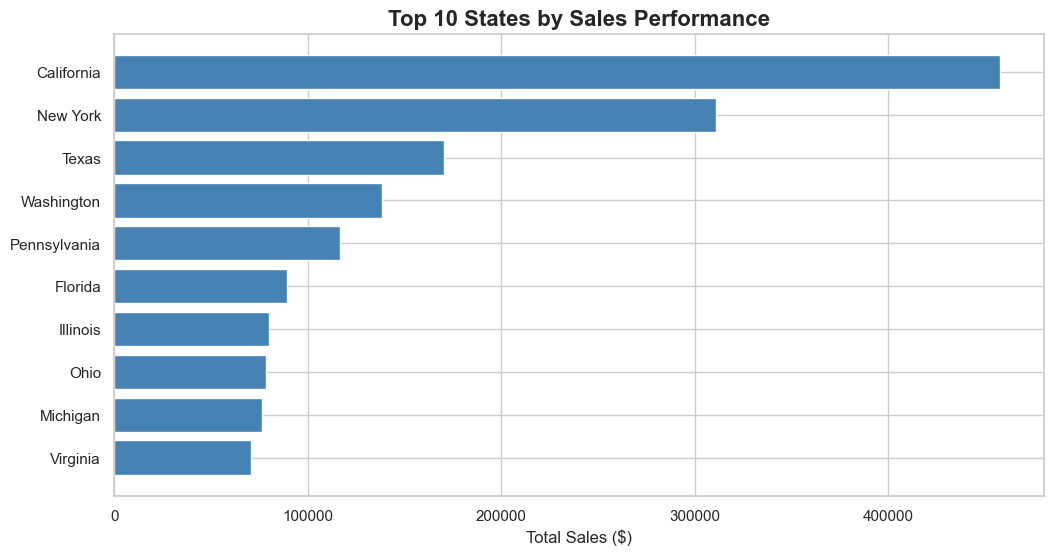

interactive(children=(IntSlider(value=10, description='Top N States:', max=25, min=5), Output()), _dom_classes…

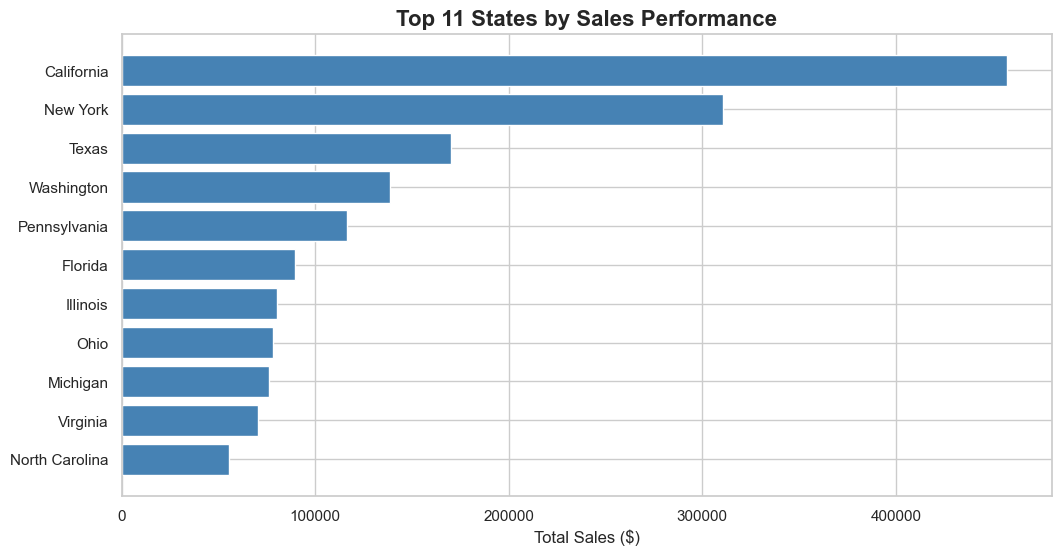

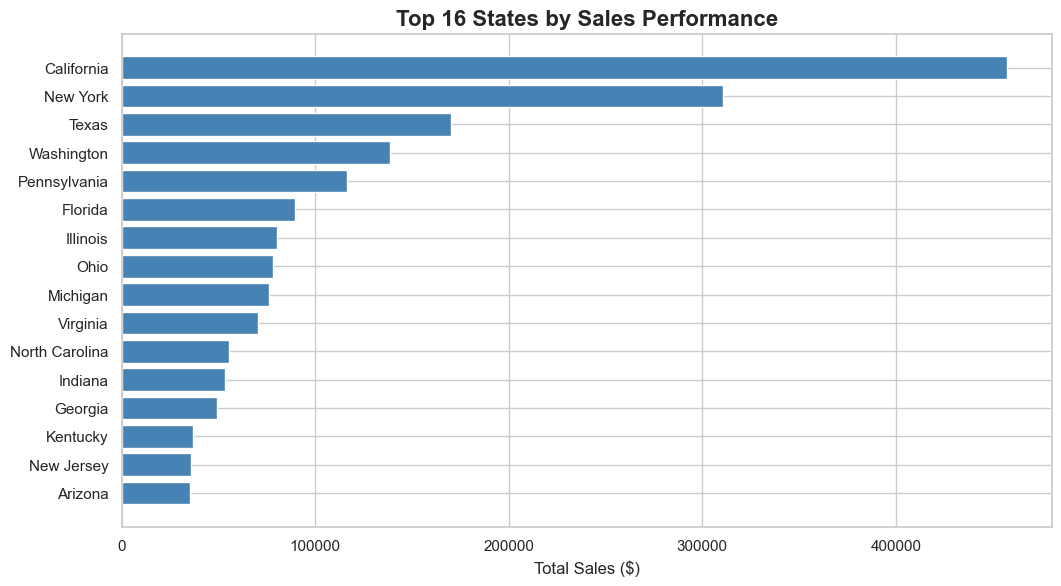

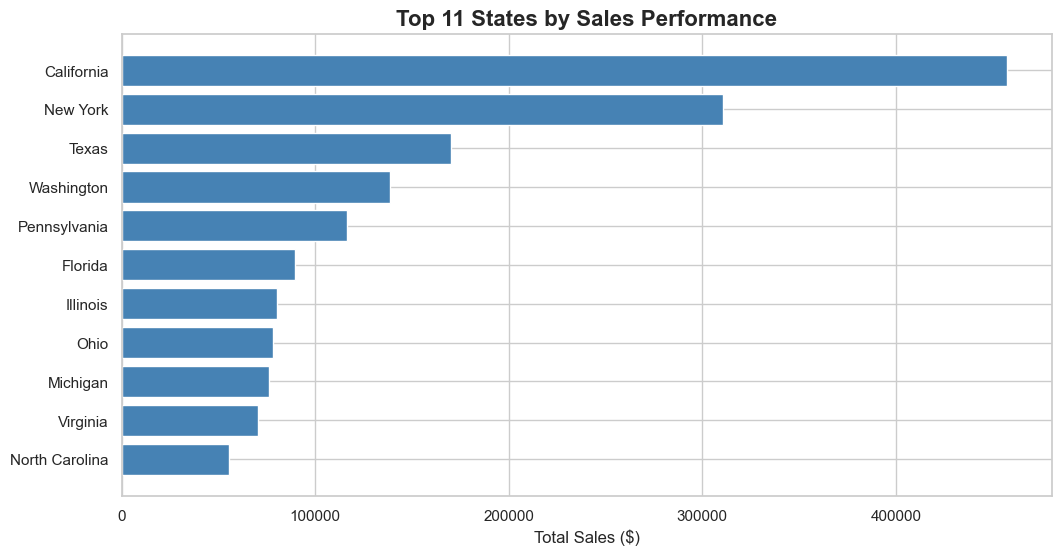

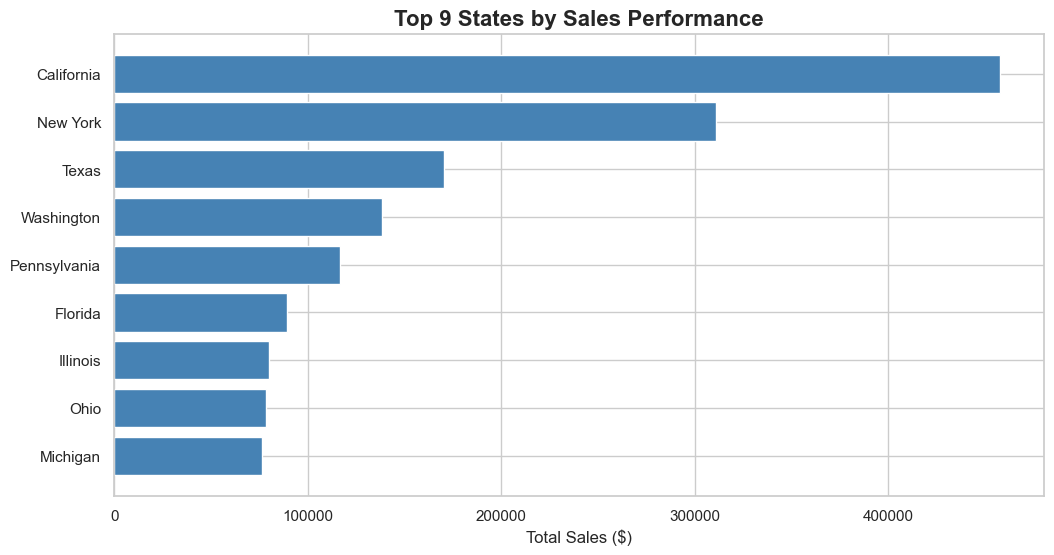

In [9]:
# Préparation des données par État
state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=True)

def plot_top_states(top_n=10):
    plt.figure(figsize=(12, max(6, top_n * 0.4)))
    top_states = state_sales.tail(top_n)

    bars = plt.barh(range(len(top_states)), top_states.values, color='steelblue')
    plt.yticks(range(len(top_states)), top_states.index)
    plt.xlabel('Total Sales ($)', fontsize=12)
    plt.title(f'Top {top_n} States by Sales Performance', fontsize=16, fontweight='bold')

    for i, (state, value) in enumerate(top_states.items()):
        plt.text(value + max(top_states.values()) * 0.01, i, f'${value:,.0f}', va='center')

    plt.tight_layout()
    plt.show()

# Widget Slider
top_n_slider = IntSlider(min=5, max=25, value=10, description='Top N States:')
interact(plot_top_states, top_n=top_n_slider);

## 3. Communicating Insights (Seaborn)
Highlighting profitability and the impact of our discount strategies.

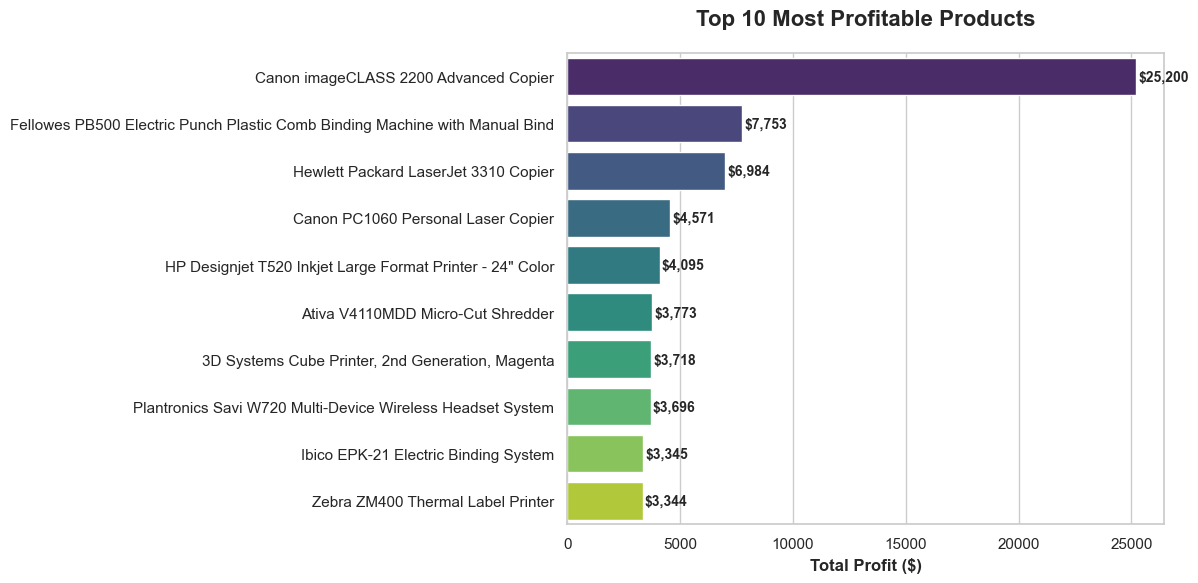

In [10]:
# Analyse des produits
product_profit = df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
ax = sns.barplot(x=product_profit.values, y=product_profit.index, palette='viridis', orient='h')

plt.title('Top 10 Most Profitable Products', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Total Profit ($)', fontsize=12, fontweight='bold')
plt.ylabel('')

# Annotations
for i, (product, profit) in enumerate(product_profit.items()):
    ax.text(profit + 100, i, f'${profit:,.0f}', va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

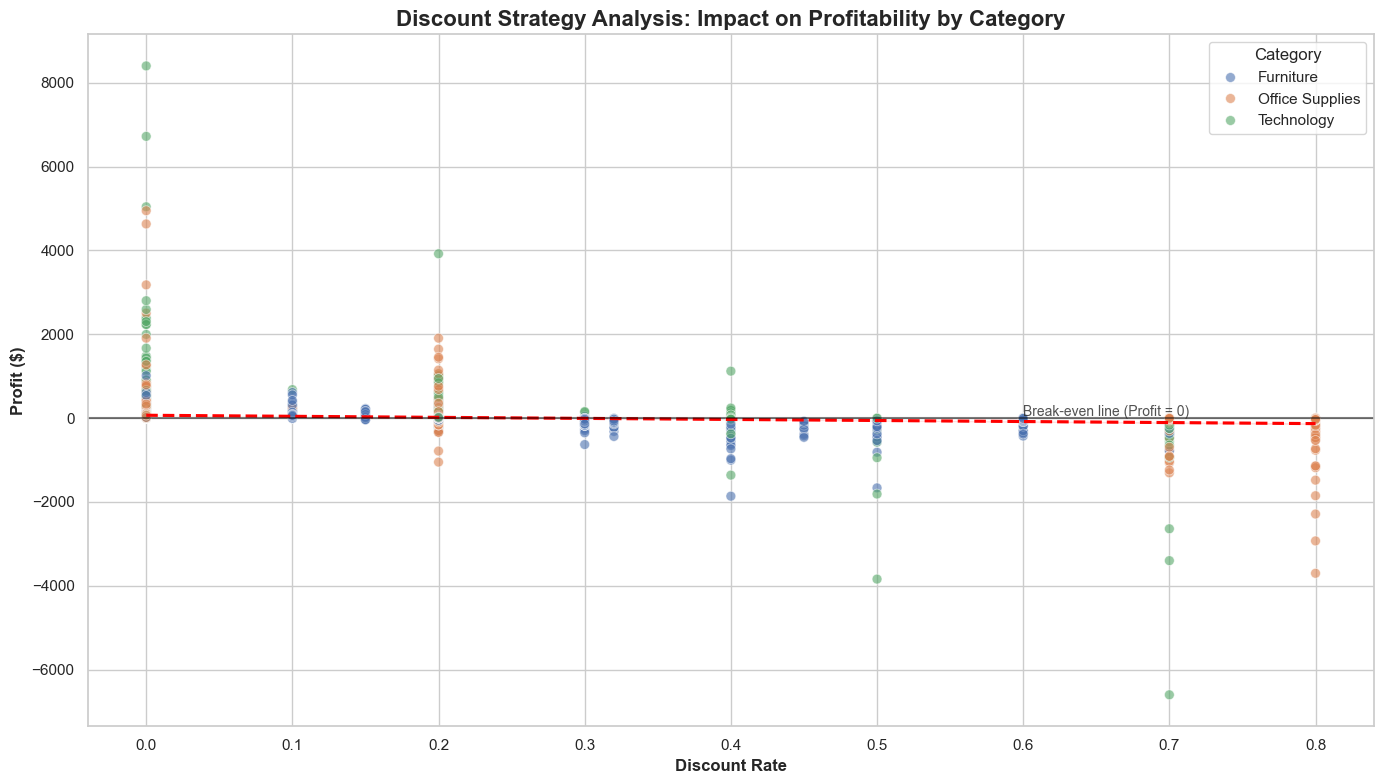

In [11]:
plt.figure(figsize=(14, 8))

# Scatter plot
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category', alpha=0.6, s=50)

# Ligne de régression (tendance)
sns.regplot(data=df, x='Discount', y='Profit', scatter=False, color='red', line_kws={'linestyle': '--'})

plt.title('Discount Strategy Analysis: Impact on Profitability by Category', fontsize=16, fontweight='bold')
plt.xlabel('Discount Rate', fontsize=12, fontweight='bold')
plt.ylabel('Profit ($)', fontsize=12, fontweight='bold')

# Ligne de point mort (Break-even)
plt.axhline(y=0, color='black', linestyle='-', alpha=0.5, linewidth=1.5)
plt.text(0.6, 50, 'Break-even line (Profit = 0)', fontsize=10, alpha=0.8)

plt.tight_layout()
plt.show()

## 4. Methodology and Tooling Review

**Matplotlib vs. Seaborn Comparison:**
* **Matplotlib:** Ideal for rapid exploration and fine-grained control. It integrates seamlessly with `ipywidgets` for dynamic analysis (as seen in our time-series and geographic charts).
* **Seaborn:** Best suited for stakeholder-facing presentations. It offers publication-ready aesthetics, built-in statistical functionalities (like the regression line in our scatter plot), and automatic color palettes.

In [13]:
# 5. Final Deliverable: Automated Executive Summary
print("=== EXECUTIVE SUMMARY - KEY FINDINGS ===\n")

total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
profit_margin = (total_profit / total_sales) * 100

print(" BUSINESS PERFORMANCE:")
print(f"• Total Revenue: ${total_sales:,.0f}")
print(f"• Total Profit: ${total_profit:,.0f}")
print(f"• Overall Profit Margin: {profit_margin:.1f}%\n")

top_state = state_sales.index[-1]
top_state_sales = state_sales.iloc[-1]
print(" GEOGRAPHIC PERFORMANCE:")
print(f"• Top performing state: {top_state} (${top_state_sales:,.0f})")
print(f"• Concentration: Top 5 states represent {(state_sales.tail(5).sum()/total_sales)*100:.1f}% of all sales.\n")

high_discount_loss_rate = (df[df['Discount'] > 0.2]['Profit'] < 0).mean() * 100
print(" DISCOUNT STRATEGY INSIGHTS:")
print(f"• High discount risk: {high_discount_loss_rate:.1f}% of transactions with >20% discount result in financial losses.")
print("• Recommendation: Limit standard discounts to a maximum of 20%. Require managerial approval for exceptions.")

=== EXECUTIVE SUMMARY - KEY FINDINGS ===

 BUSINESS PERFORMANCE:
• Total Revenue: $2,297,201
• Total Profit: $286,397
• Overall Profit Margin: 12.5%

 GEOGRAPHIC PERFORMANCE:
• Top performing state: California ($457,688)
• Concentration: Top 5 states represent 52.0% of all sales.

 DISCOUNT STRATEGY INSIGHTS:
• High discount risk: 96.8% of transactions with >20% discount result in financial losses.
• Recommendation: Limit standard discounts to a maximum of 20%. Require managerial approval for exceptions.


## Advanced Challenges
Dashboarding, Outlier Detection, and Interactive Web Plotting.

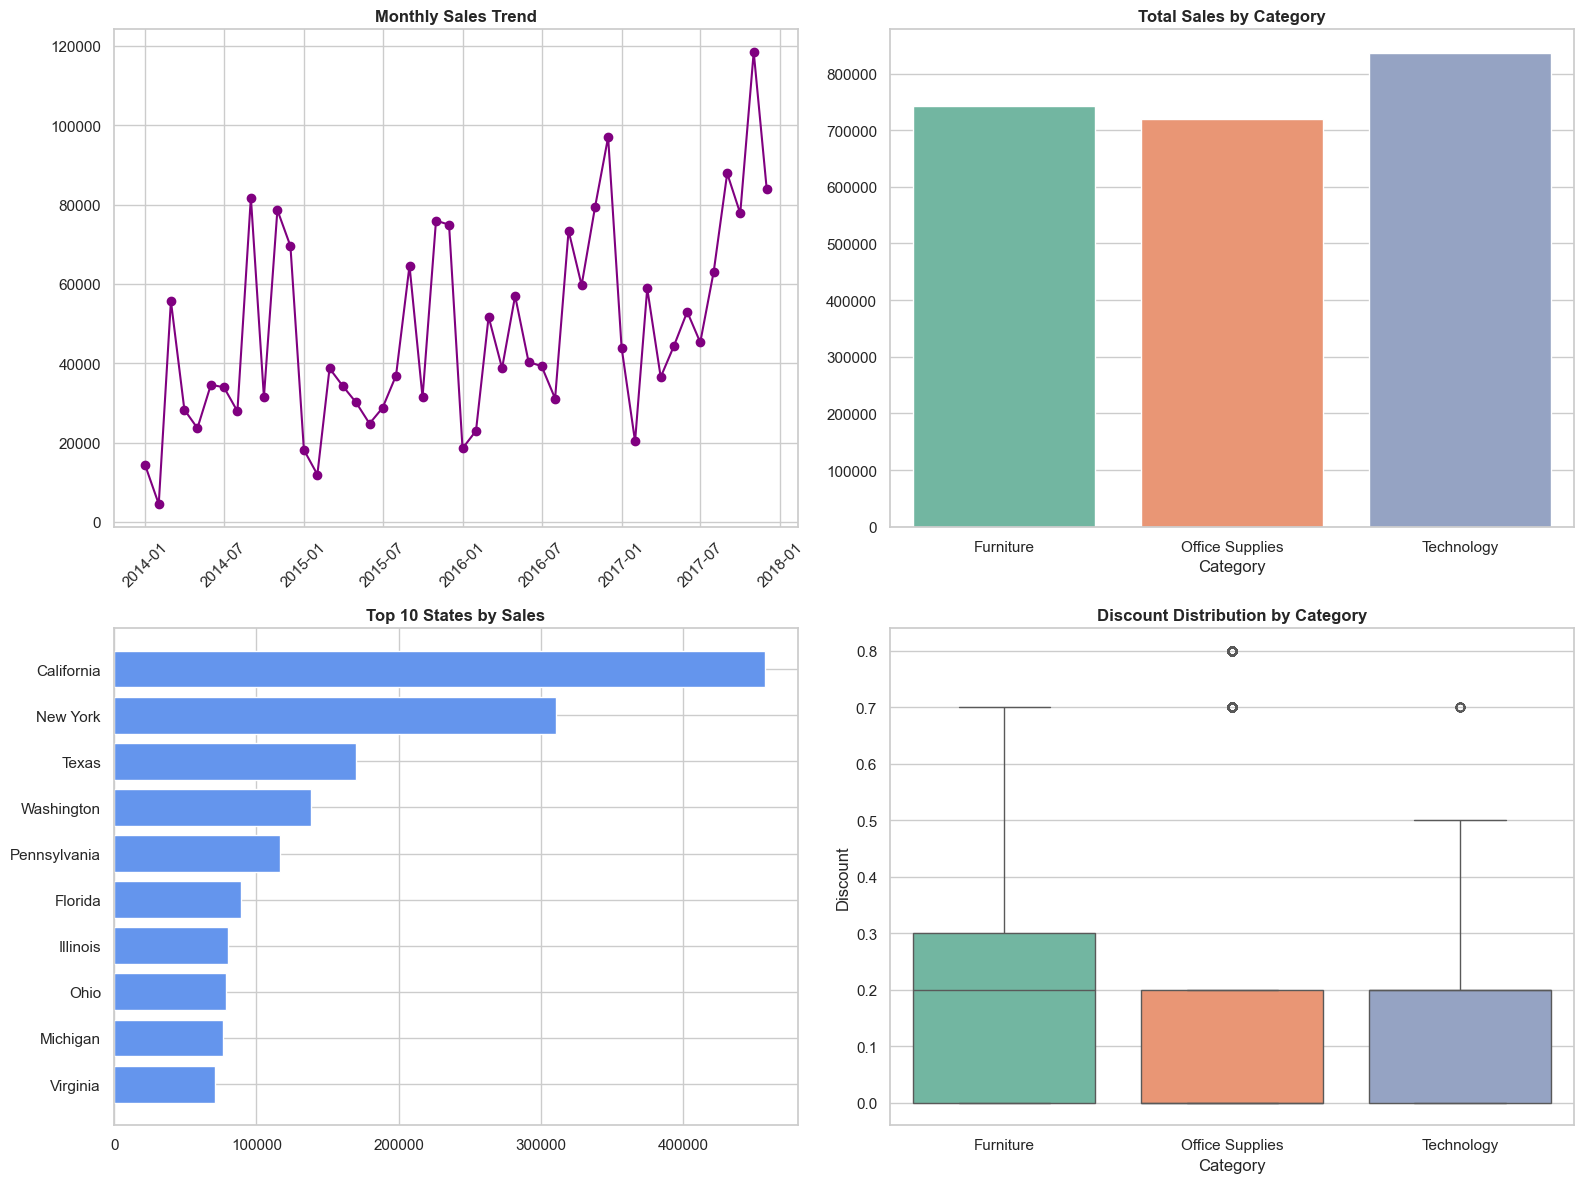

In [14]:
# Création d'un Dashboard statique
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 1. Sales Trend
monthly_total = df.groupby('Order Month-Year')['Sales'].sum()
ax1.plot(monthly_total.index.to_timestamp(), monthly_total.values, marker='o', color='purple')
ax1.set_title('Monthly Sales Trend', fontweight='bold')
ax1.tick_params(axis='x', rotation=45)

# 2. Sales by Category
category_sales = df.groupby('Category')['Sales'].sum()
sns.barplot(x=category_sales.index, y=category_sales.values, ax=ax2, palette='Set2')
ax2.set_title('Total Sales by Category', fontweight='bold')

# 3. Top 10 States
top_10 = state_sales.tail(10)
ax3.barh(range(len(top_10)), top_10.values, color='cornflowerblue')
ax3.set_yticks(range(len(top_10)))
ax3.set_yticklabels(top_10.index)
ax3.set_title('Top 10 States by Sales', fontweight='bold')

# 4. Discount Boxplot
sns.boxplot(data=df, x='Category', y='Discount', ax=ax4, palette='Set2')
ax4.set_title('Discount Distribution by Category', fontweight='bold')

plt.tight_layout()
plt.show()

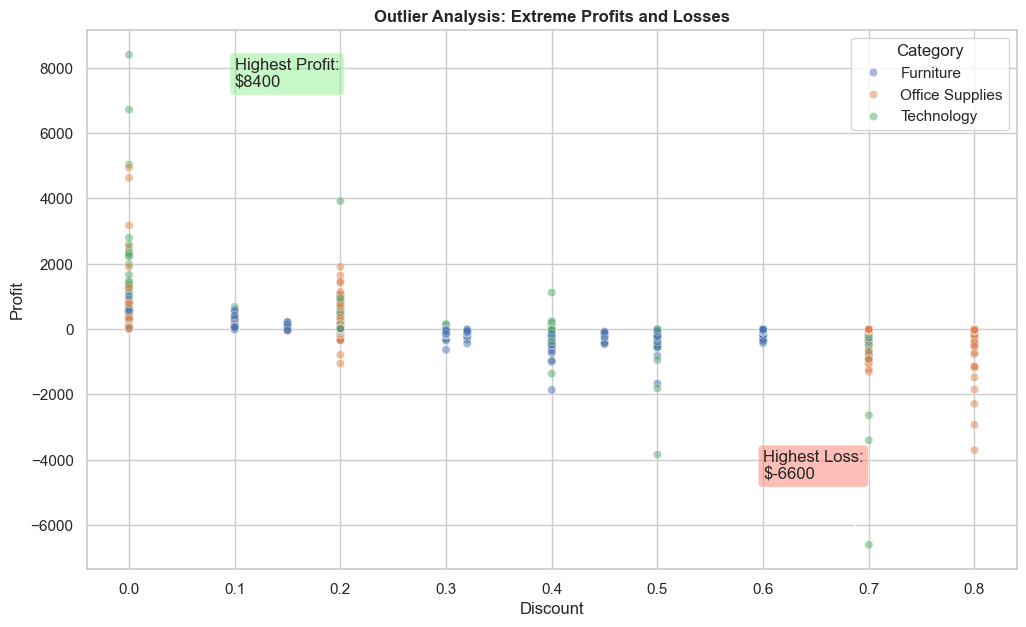

In [15]:
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category', alpha=0.5)

# Identification des extrêmes
best_sale = df.loc[df['Profit'].idxmax()]
worst_sale = df.loc[df['Profit'].idxmin()]

# Annotation du meilleur
plt.annotate(f"Highest Profit:\n${best_sale['Profit']:.0f}", 
            xy=(best_sale['Discount'], best_sale['Profit']),
            xytext=(best_sale['Discount']+0.1, best_sale['Profit']-1000),
            arrowprops=dict(facecolor='green', arrowstyle='->'),
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.5))

# Annotation du pire
plt.annotate(f"Highest Loss:\n${worst_sale['Profit']:.0f}", 
            xy=(worst_sale['Discount'], worst_sale['Profit']),
            xytext=(worst_sale['Discount']-0.1, worst_sale['Profit']+2000),
            arrowprops=dict(facecolor='red', arrowstyle='->'),
            bbox=dict(boxstyle='round,pad=0.3', facecolor='salmon', alpha=0.5))

plt.title('Outlier Analysis: Extreme Profits and Losses', fontweight='bold')
plt.show()

In [18]:
import plotly.express as px

# Création d'un graphique interactif Plotly
fig = px.scatter(df, x='Discount', y='Profit', color='Category',
                 hover_data=['State', 'Product Name', 'Sales'], 
                 title='Interactive Discount vs Profit Analysis (Hover over points!)',
                 opacity=0.6)

fig.update_layout(height=600)
# Décommente la ligne ci-dessous si tu veux l'afficher dans ton notebook local
# fig.show()

print("\n Plotly vs Matplotlib : Plotly offre une interactivité native (zoom, survol pour voir les détails d'une transaction exacte) sans avoir besoin d'écrire des widgets complexes, parfait pour des tableaux de bord web exploratoires.")


 Plotly vs Matplotlib : Plotly offre une interactivité native (zoom, survol pour voir les détails d'une transaction exacte) sans avoir besoin d'écrire des widgets complexes, parfait pour des tableaux de bord web exploratoires.
